In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

In [296]:
df=pd.read_csv('Project11.csv')
df

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [297]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [298]:
df.shape

(366, 12)

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [300]:
df.columns = df.columns.str.strip()

In [301]:
df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [302]:
df=df.drop(columns=["day"])

In [303]:
print(df.isnull().sum())

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64


In [304]:
df["winddirection"] = df["winddirection"].fillna(df["winddirection"].mode()[0])
df["windspeed"] = df["windspeed"].fillna(df["windspeed"].median())

In [305]:
df["rainfall"].unique()

array(['yes', 'no'], dtype=object)

In [306]:
from sklearn.preprocessing import LabelEncoder

In [307]:
le_rainfall = LabelEncoder()
df["rainfall"] = le_rainfall.fit_transform(df["rainfall"])

In [308]:
df.head(15)

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7
5,1018.8,24.3,20.9,19.2,18.0,84,51,1,7.7,20.0,14.5
6,1021.8,21.4,18.8,17.0,15.0,79,56,0,3.4,30.0,21.5
7,1020.8,21.0,18.4,16.5,14.4,78,28,0,7.7,60.0,14.3
8,1020.6,18.9,18.1,17.1,14.3,78,79,0,3.3,70.0,39.3
9,1017.5,18.5,18.0,17.2,15.5,85,91,1,0.0,70.0,37.7


In [309]:
sns.set(style="whitegrid")

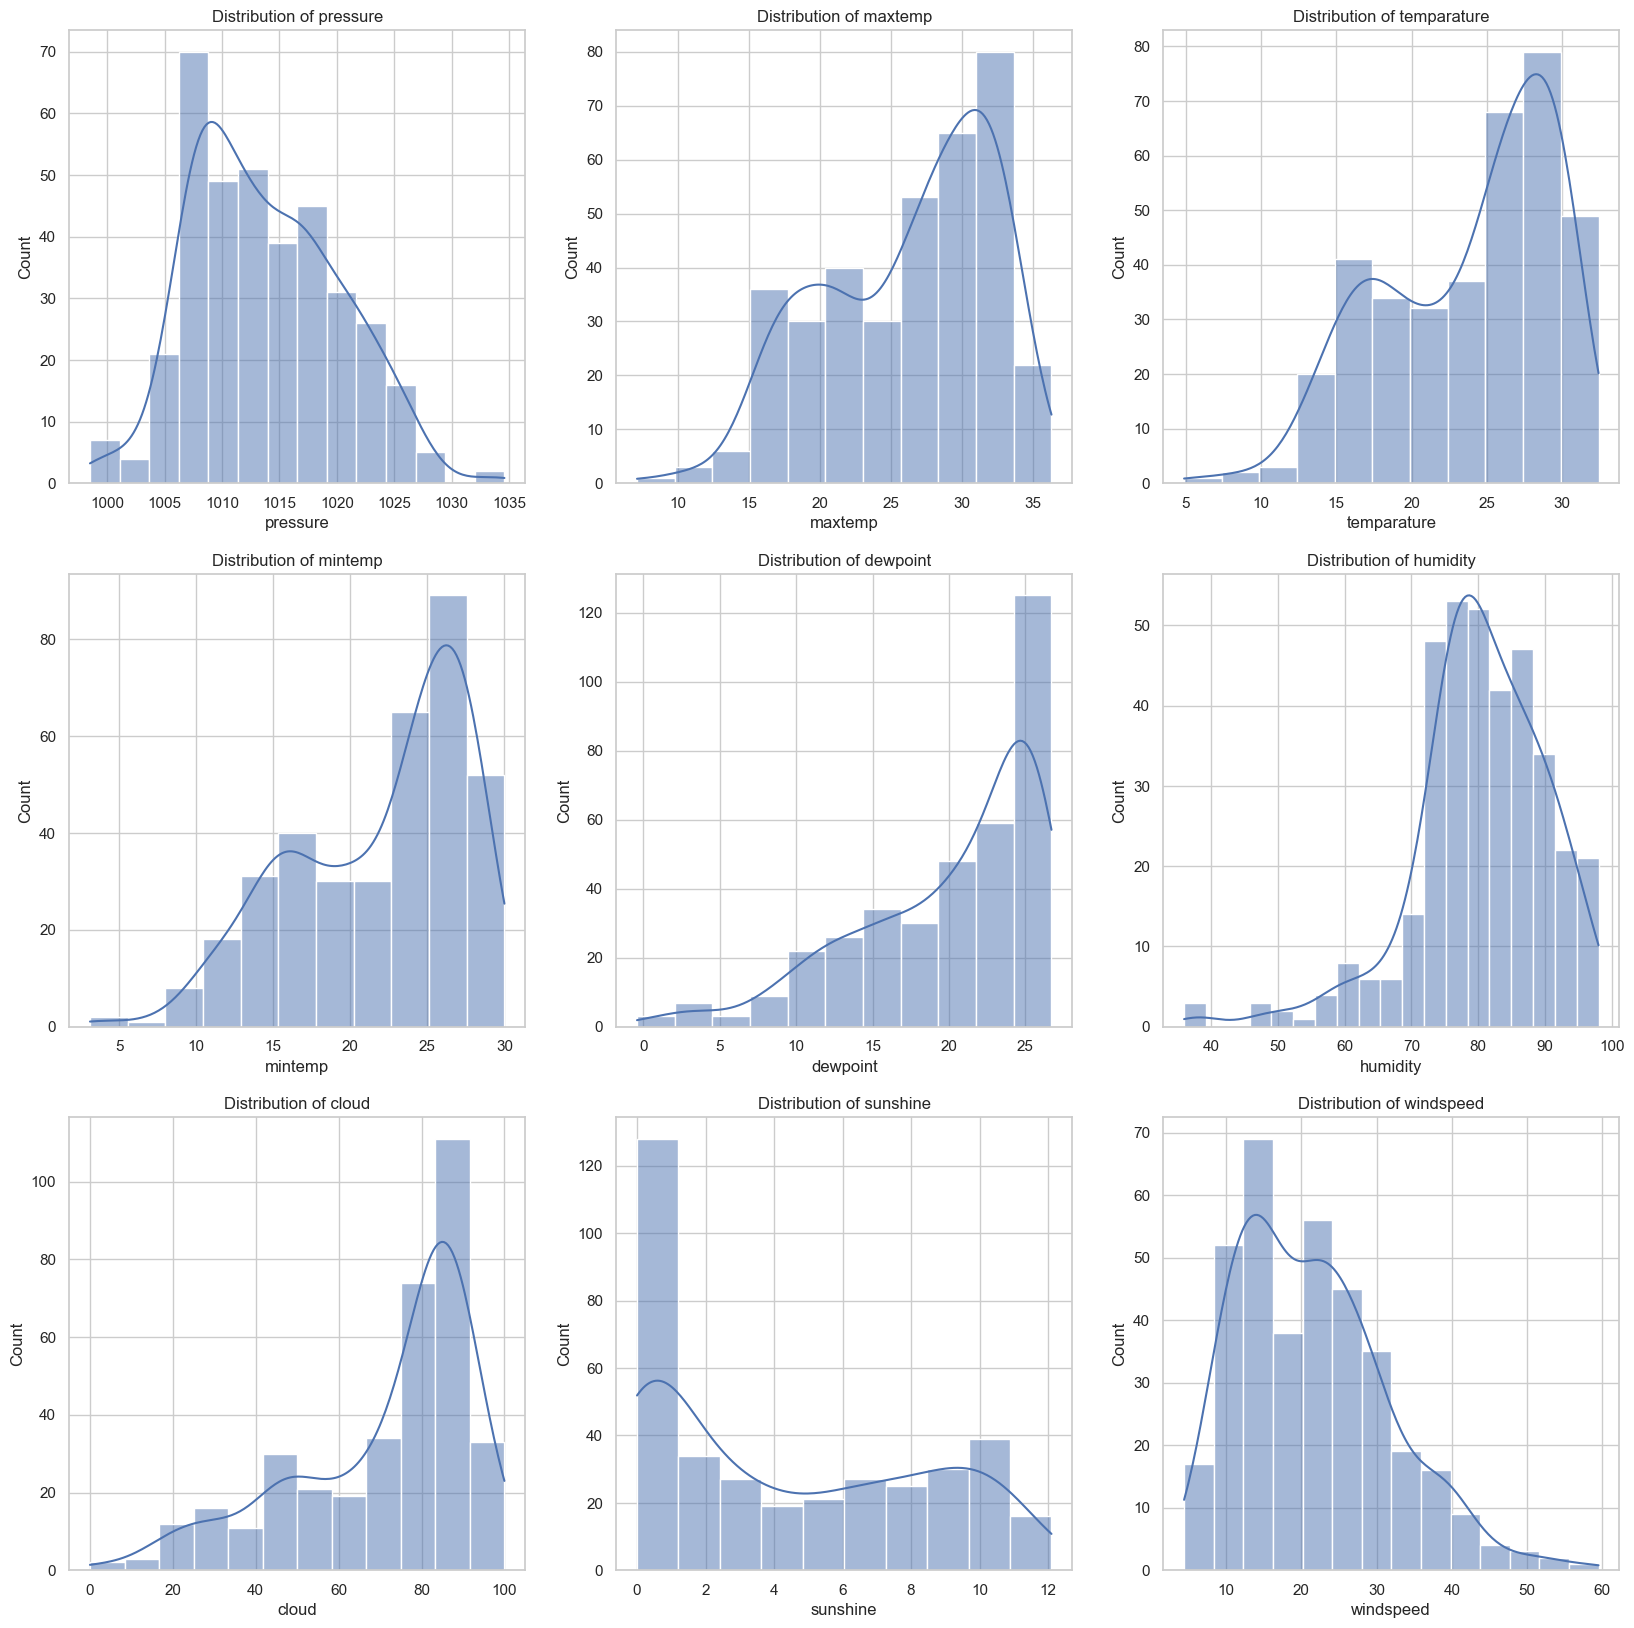

In [310]:
plt.figure(figsize=(20, 20))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.histplot(df[column], kde=True)
  plt.title(f"Distribution of {column}")

plt.show()

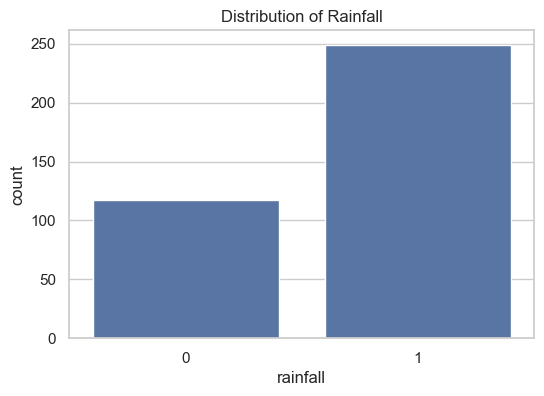

In [311]:
plt.figure(figsize=(6, 4))
sns.countplot(x="rainfall", data=df)
plt.title("Distribution of Rainfall")
plt.show()

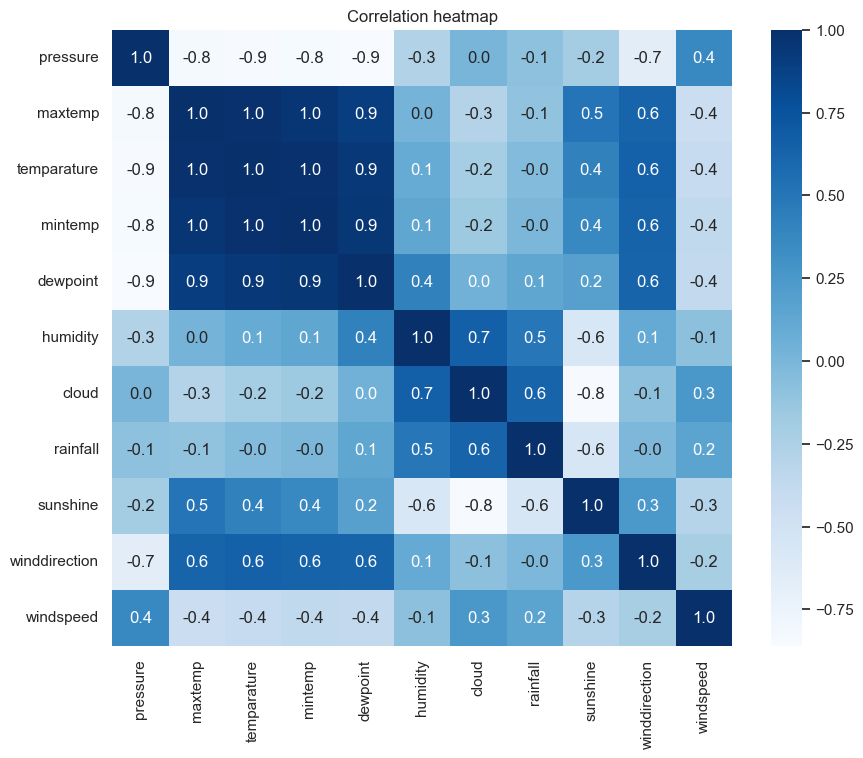

In [312]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".1f")
plt.title("Correlation heatmap")
plt.show()

In [313]:
df=df.drop(columns=['maxtemp', 'temparature', 'mintemp'])

In [314]:
df['rainfall'].value_counts()

rainfall
1    249
0    117
Name: count, dtype: int64

In [315]:
x=df.drop(columns=["rainfall"])
y=df["rainfall"]

In [316]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [317]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_resampled)

pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(x_scaled)

In [318]:
x_train,x_test,y_train,y_test=train_test_split(x_pca,y_resampled,test_size=0.2,random_state=42)

In [319]:
model=RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100,200],
    "max_features": ["sqrt"],
    "max_depth": [8,10,12],
    "min_samples_split": [5,10],
    "min_samples_leaf": [2,4],
    "bootstrap": [True]
}

In [320]:
grid_search_rf = GridSearchCV(estimator=model, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

grid_search_rf.fit(x_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [8, 10, 12],
                         'max_features': ['sqrt'], 'min_samples_leaf': [2, 4],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             verbose=2)

In [321]:
best_rf_model = grid_search_rf.best_estimator_

print("best parameters for Random Forest:", grid_search_rf.best_params_)

best parameters for Random Forest: {'bootstrap': True, 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [322]:
cv_scores = cross_val_score(best_rf_model, x_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", np.mean(cv_scores))

Cross-validation scores: [0.825      0.825      0.8125     0.82278481 0.86075949]
Mean cross-validation score: 0.8292088607594936


In [323]:
y_pred = best_rf_model.predict(x_test)

acc2=accuracy_score(y_test, y_pred)
acc2

0.82